In [1]:
import kagglehub
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")

100%|██████████| 292k/292k [00:00<00:00, 63.4MB/s]

Extracting files...


In [2]:
import os
import pandas as pd

# List contents of the downloaded path to find the CSV file
data_files = os.listdir(path)
print(f"Files in the dataset directory: {data_files}")

Files in the dataset directory: ['Car details v3.csv', 'car details v4.csv', 'car data.csv', 'CAR DETAILS FROM CAR DEKHO.csv']


In [3]:
# Assuming the CSV file is named 'Car details v3.csv' based on typical Kaggle datasets, or check the file list.
# Let's try to load 'Car details v3.csv' or the first csv file found.

csv_file = None
for f in data_files:
    if f.endswith('.csv'):
        csv_file = f
        break

if csv_file:
    data_filepath = os.path.join(path, csv_file)
    df = pd.read_csv(data_filepath)
    print(f"Loaded data from: {data_filepath}")

    # Display the first 5 rows of the DataFrame
    display(df.head())

    # Display basic information about the DataFrame
    display(df.info())
else:
    print("No CSV file found in the downloaded dataset directory.")

Loaded data from: /root/.cache/kagglehub/datasets/nehalbirla/vehicle-dataset-from-cardekho/versions/4/Car details v3.csv


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


None

Now that we have loaded the data, we can proceed with a more in-depth exploratory data analysis (EDA). This will help us understand the distributions of features, identify any missing values, and discover relationships between variables, which will be crucial for building the Streamlit app.

In [4]:
# Step 1: Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0
transmission       0
owner              0
mileage          221
engine           221
max_power        215
torque           222
seats            221
dtype: int64


The missing value check shows that `mileage`, `engine`, `max_power`, `torque`, and `seats` have missing values. Additionally, `mileage`, `engine`, `max_power`, and `torque` are currently stored as `object` types, indicating they contain mixed data or strings that need cleaning before numerical analysis. Let's proceed to clean and convert these columns.

In [5]:
# Step 2: Data Cleaning and Type Conversion for 'mileage', 'engine', 'max_power'

# Function to extract numeric value from string
def extract_numeric(value):
    if isinstance(value, str):
        import re
        match = re.search(r'\d+\.?\d*', value)
        if match:
            return float(match.group(0))
    return value

# Clean 'mileage' column
df['mileage'] = df['mileage'].apply(extract_numeric)
df['mileage'] = pd.to_numeric(df['mileage'], errors='coerce') # Coerce non-numeric to NaN

# Clean 'engine' column
df['engine'] = df['engine'].apply(extract_numeric)
df['engine'] = pd.to_numeric(df['engine'], errors='coerce') # Coerce non-numeric to NaN

# Clean 'max_power' column
df['max_power'] = df['max_power'].apply(extract_numeric)
df['max_power'] = pd.to_numeric(df['max_power'], errors='coerce') # Coerce non-numeric to NaN

# For 'torque', it's a bit more complex as it often includes RPMs. Let's try to extract the primary torque value.
# Example: '250Nm@ 1500-2500rpm' -> 250
def extract_torque(value):
    if isinstance(value, str):
        import re
        # Look for a number followed by 'Nm' or 'kgm' and try to get that number
        match_nm = re.search(r'(\d+\.?\d*)\s*Nm', value)
        if match_nm:
            return float(match_nm.group(1))
        match_kgm = re.search(r'(\d+\.?\d*)\s*kgm', value)
        if match_kgm:
            return float(match_kgm.group(1)) * 9.80665 # Convert kgm to Nm (approx)

        # Fallback: if no unit, just try to get the first number (might not be accurate for all cases)
        match_num = re.search(r'\d+\.?\d*', value)
        if match_num:
            return float(match_num.group(0))
    return value

df['torque'] = df['torque'].apply(extract_torque)
df['torque'] = pd.to_numeric(df['torque'], errors='coerce') # Coerce non-numeric to NaN

# Impute missing values with the median for numerical columns after conversion
for col in ['mileage', 'engine', 'max_power', 'torque', 'seats']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# Verify types and missing values after cleaning
print("\nDataFrame info after cleaning and imputation:\n")
display(df.info())
print("\nMissing values after cleaning and imputation:\n", df.isnull().sum())


DataFrame info after cleaning and imputation:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        8128 non-null   float64
 9   engine         8128 non-null   float64
 10  max_power      8128 non-null   float64
 11  torque         8128 non-null   float64
 12  seats          8128 non-null   float64
dtypes: float64(5), int64(3), object(5)
memory usage: 825.6+ KB


/tmp/ipykernel_2848/2642874249.py:50: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


None


Missing values after cleaning and imputation:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
mileage          0
engine           0
max_power        0
torque           0
seats            0
dtype: int64


With the data cleaned and types converted, we can now proceed with more in-depth exploratory data analysis. This will include univariate analysis of numerical and categorical features, and then bivariate analysis to understand relationships between features, especially how they relate to the `selling_price`.

## Exploratory Data Analysis (EDA)

### 1. Univariate Analysis - Numerical Features

Descriptive statistics for numerical columns:



,year,selling_price,km_driven,mileage,engine,max_power,torque,seats
count,8128.000000,8.128000e+03,8.128000e+03,8128.000000,8128.00000,8128.000000,8128.000000,8128.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.415554,1452.89813,91.264982,169.750272,5.405389
std,4.044249,8.062534e+05,5.655055e+04,3.981922,498.19672,35.376388,94.737664,0.948874
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.00000,0.000000,5.700000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.800000,1197.00000,68.100000,109.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.00000,82.000000,160.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.277500,1582.00000,101.250000,202.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.00000,400.000000,789.000000,14.000000


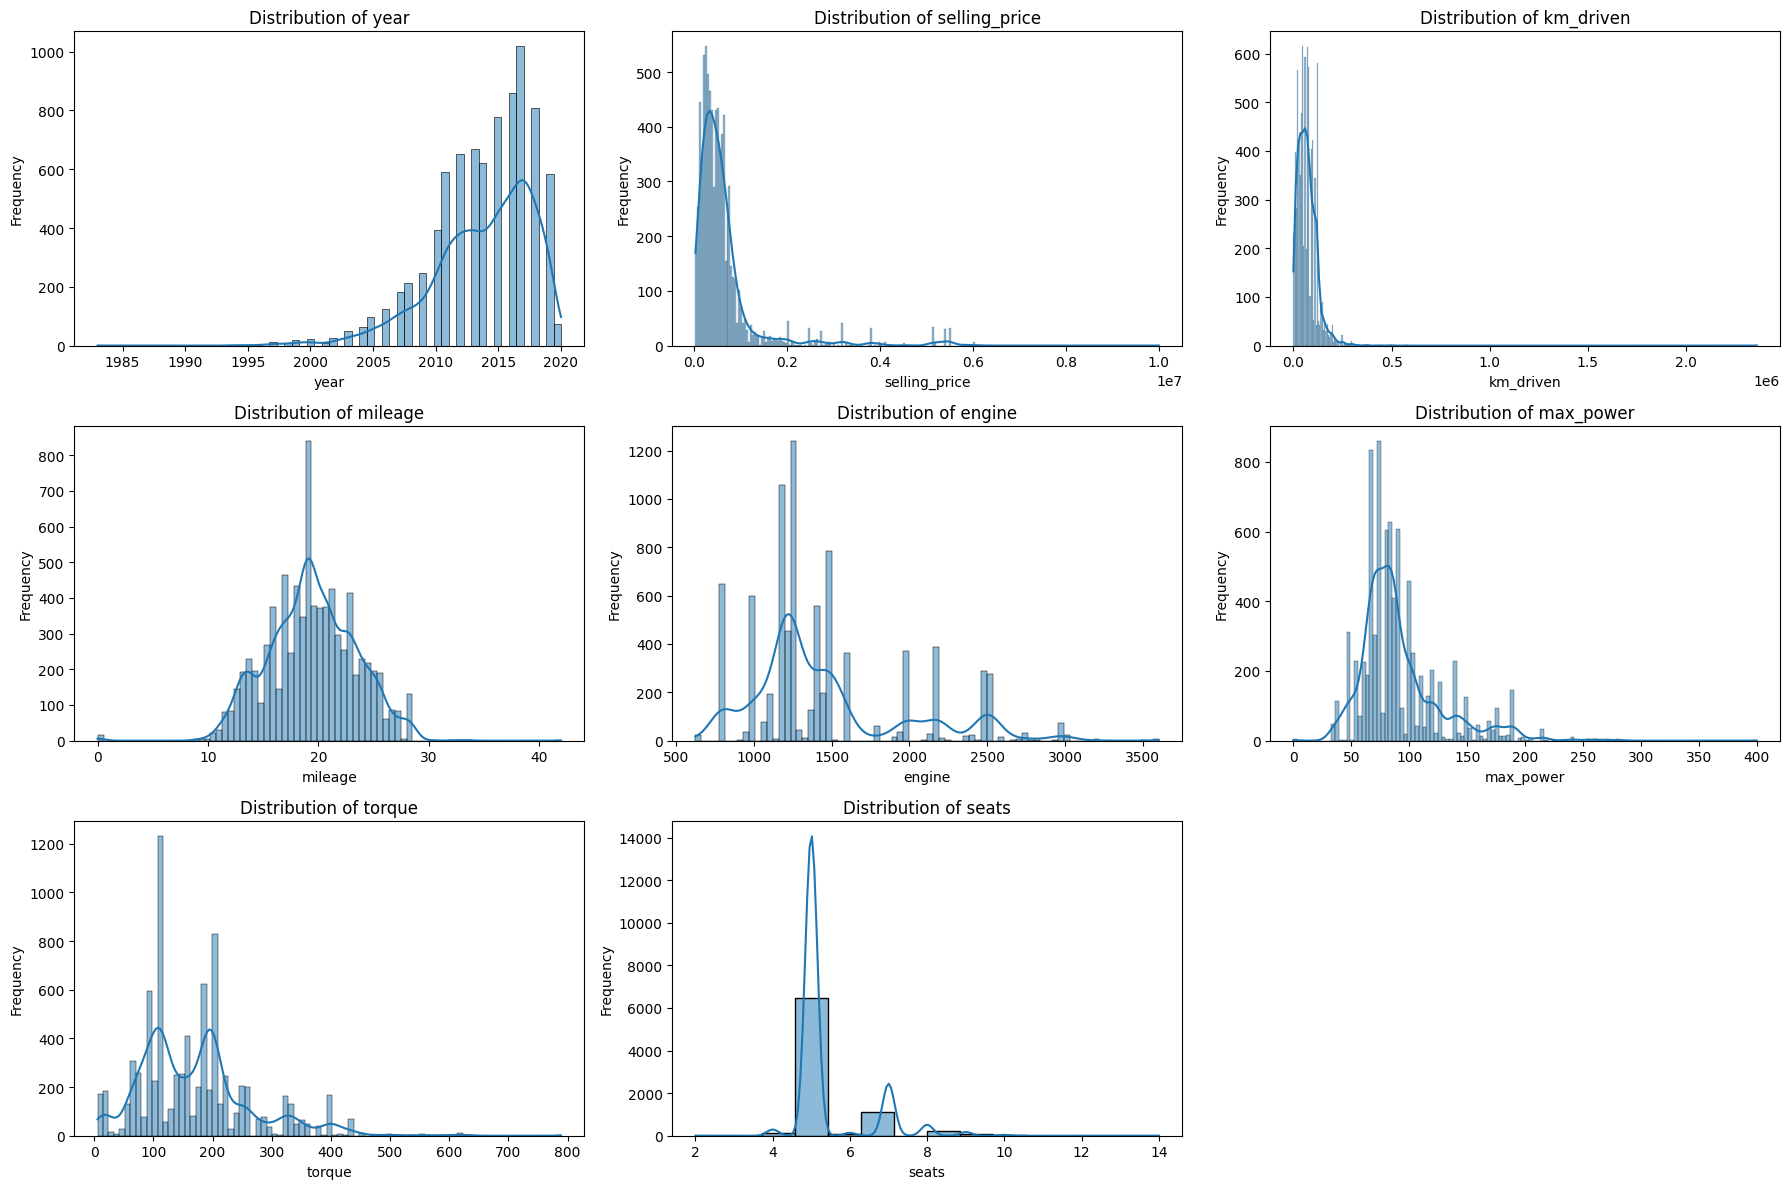

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Display descriptive statistics for numerical columns
print("Descriptive statistics for numerical columns:\n")
display(df.describe())

# Plot histograms for numerical columns
numerical_cols = ['year', 'selling_price', 'km_driven', 'mileage', 'engine', 'max_power', 'torque', 'seats']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### 2. Univariate Analysis - Categorical Features

/tmp/ipykernel_2848/2315763852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2848/2315763852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2848/2315763852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_2848/2315763852.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `leg

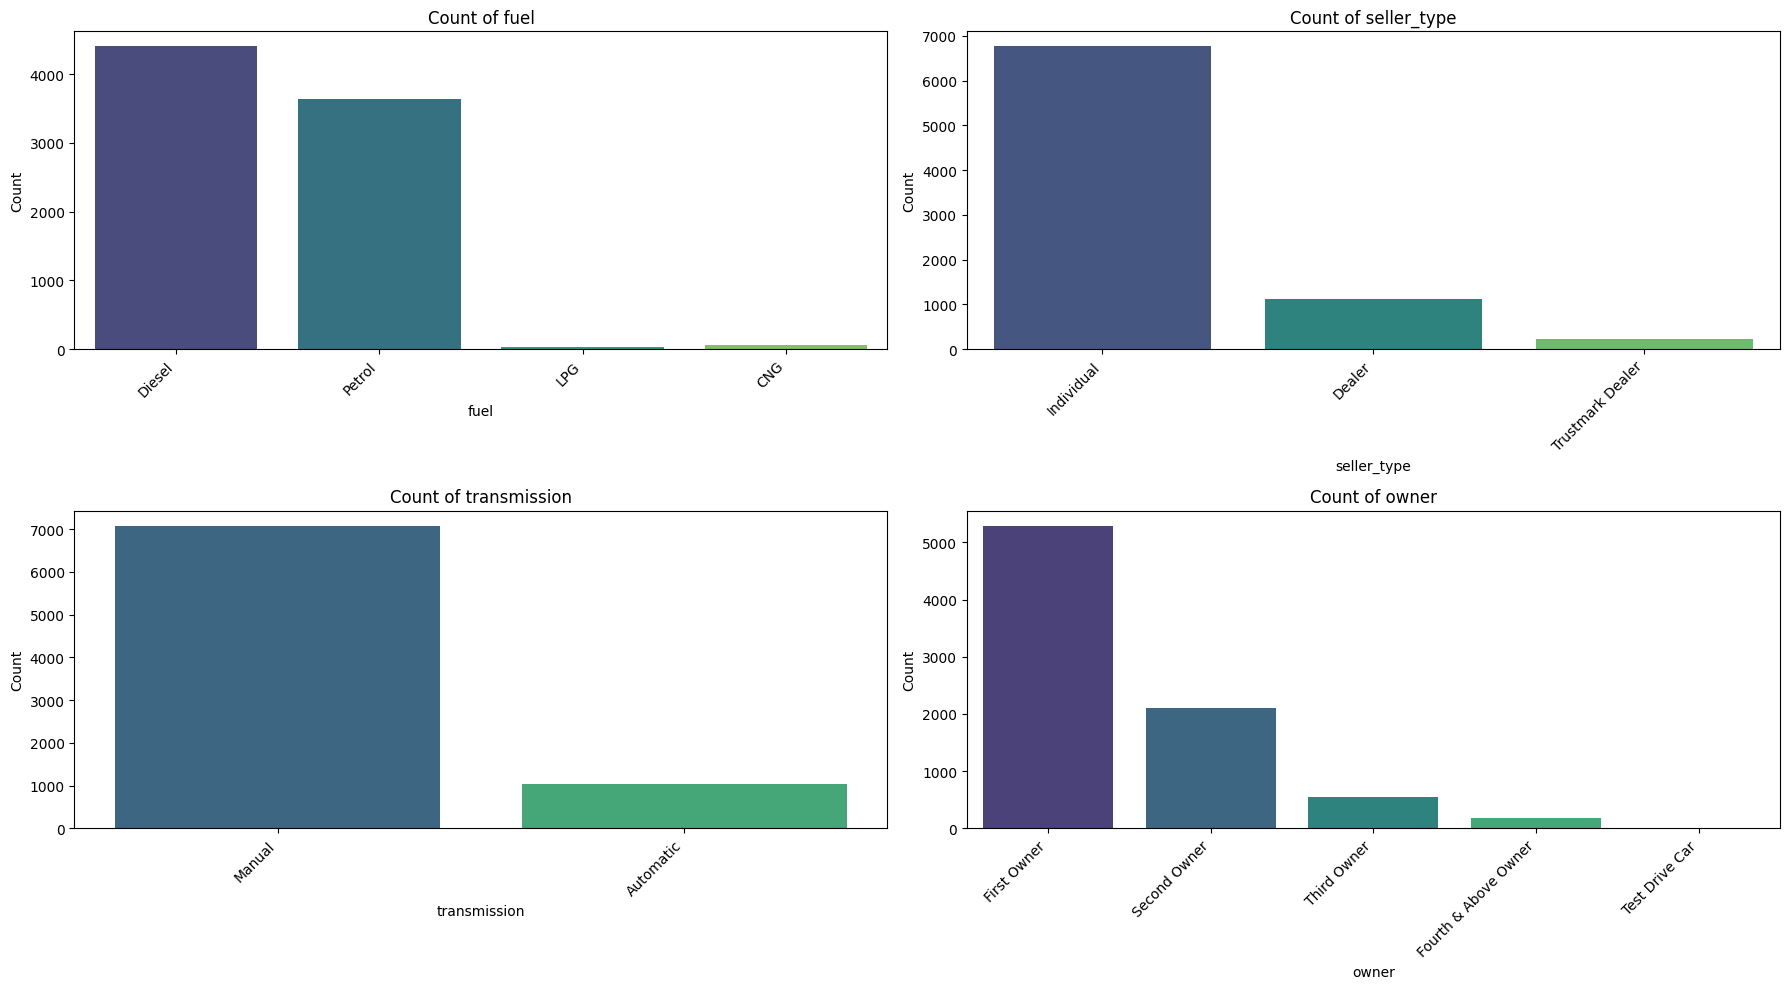


Top 10 most frequent car names:



,count
name,
Maruti Swift Dzire VDI,129
Maruti Alto 800 LXI,82
Maruti Alto LXi,71
BMW X4 M Sport X xDrive20d,62
Maruti Swift VDI,61
Maruti Swift VDI BSIV,59
Maruti Wagon R LXI,53
Maruti Alto K10 VXI,50
Hyundai EON Era Plus,48


In [7]:
# Display value counts and count plots for categorical columns
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

# For 'name', display top 10 most frequent car names
print("\nTop 10 most frequent car names:\n")
display(df['name'].value_counts().head(10))

The univariate analysis provides a good overview of the individual feature distributions. Next, we will perform bivariate analysis to understand the relationships between features, particularly how they influence the `selling_price`.

### 3. Bivariate Analysis

#### Numerical Features vs. Selling Price

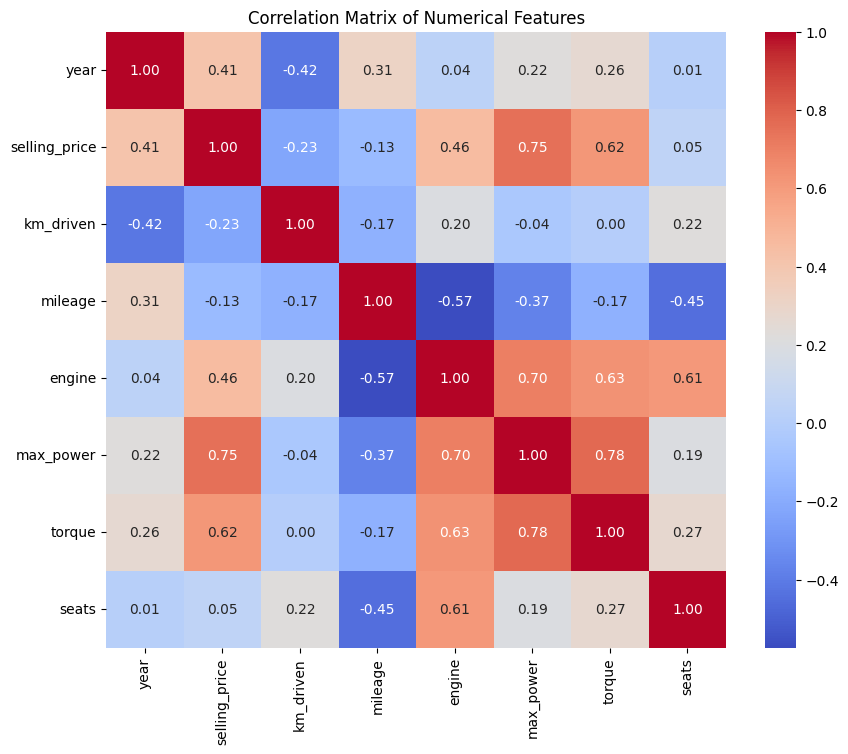

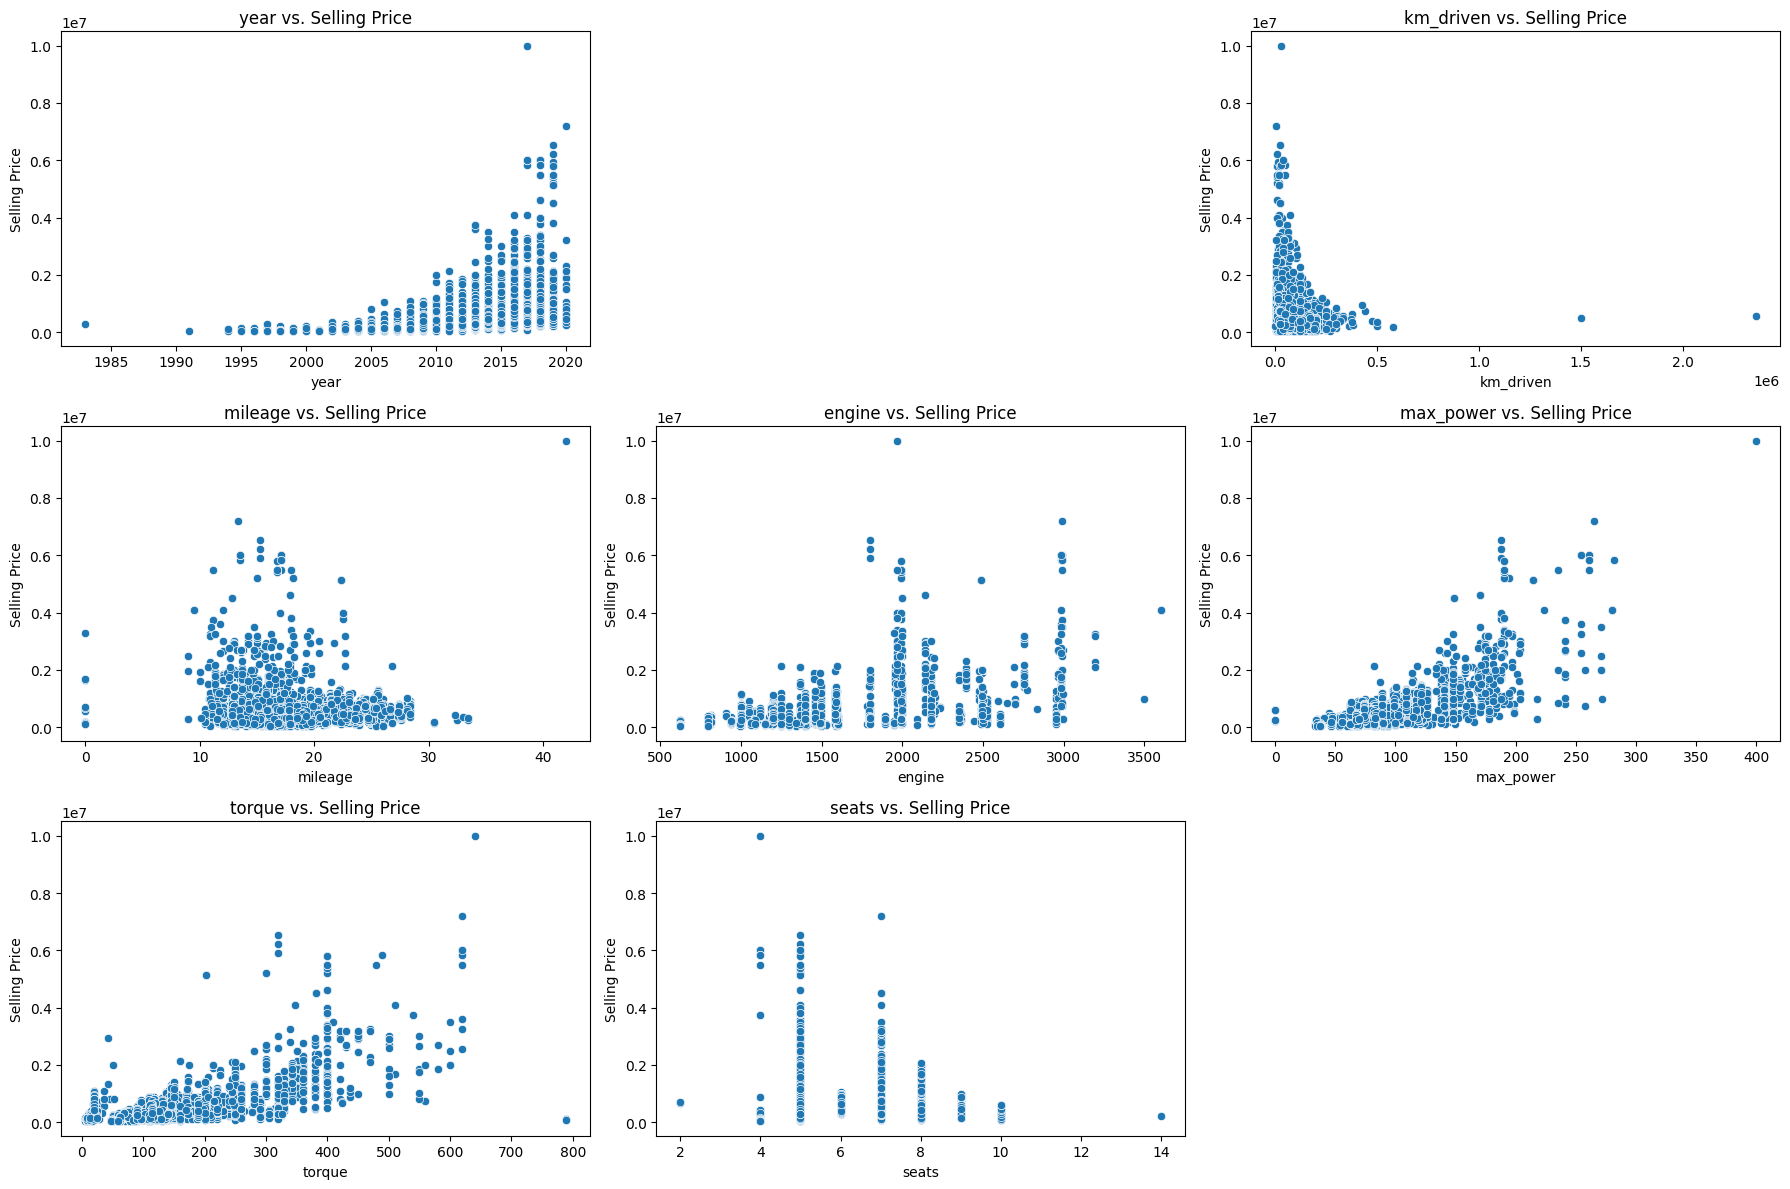

In [8]:
# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Scatter plots of numerical features vs. selling_price
plt.figure(figsize=(18, 12))
for i, col in enumerate(numerical_cols):
    if col != 'selling_price': # Exclude selling_price plotting against itself
        plt.subplot(3, 3, i + 1)
        sns.scatterplot(data=df, x=col, y='selling_price')
        plt.title(f'{col} vs. Selling Price')
        plt.xlabel(col)
        plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

#### Categorical Features vs. Selling Price

/tmp/ipykernel_2848/3407197246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='selling_price', palette='viridis')
/tmp/ipykernel_2848/3407197246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='selling_price', palette='viridis')
/tmp/ipykernel_2848/3407197246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y='selling_price', palette='viridis')
/tmp/ipykernel_2848/3407197246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

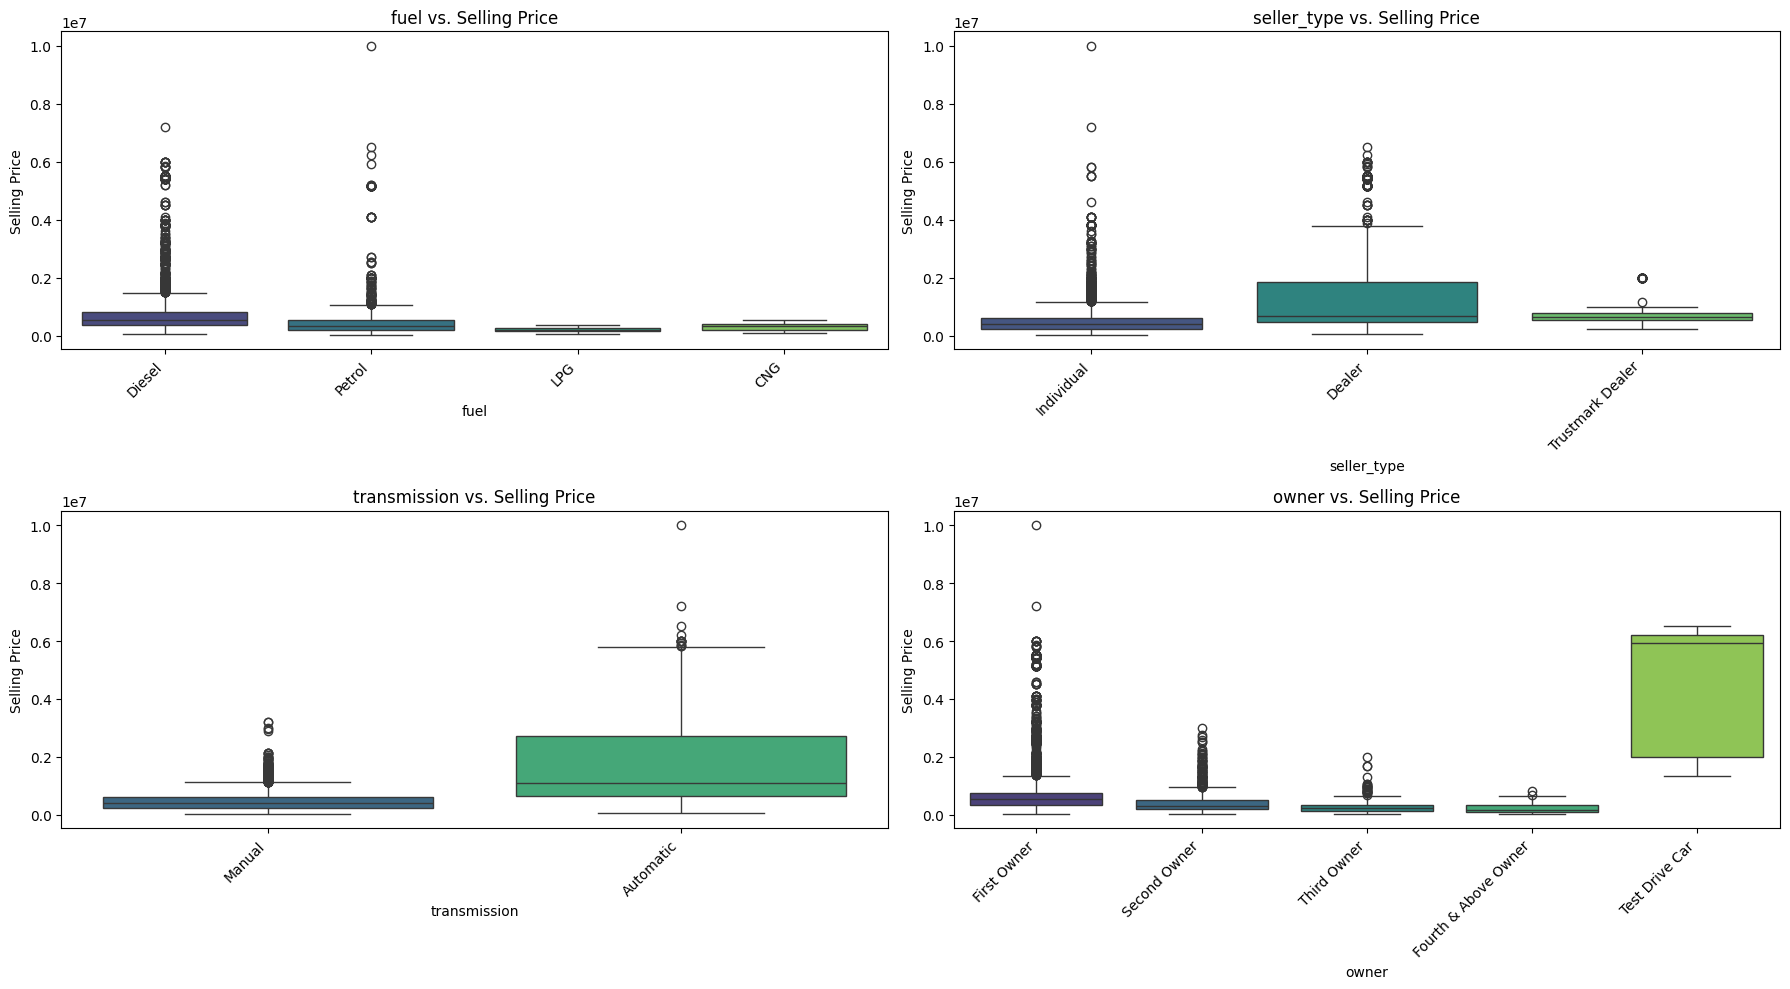

In [9]:
# Box plots of categorical features vs. selling_price
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x=col, y='selling_price', palette='viridis')
    plt.title(f'{col} vs. Selling Price')
    plt.xlabel(col)
    plt.ylabel('Selling Price')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The bivariate analysis has provided insights into how various features correlate with `selling_price`. This understanding is crucial for feature selection and engineering, which will be the next step in preparing our data for a machine learning model, and ultimately, building the Streamlit app.

## Feature Engineering and Selection

### 1. Feature Engineering

In [10]:
# Extract car brand from 'name' column
df['brand'] = df['name'].apply(lambda x: x.split(' ')[0])

# Calculate car age from 'year'
current_year = 2024 # Assuming current year for age calculation
df['car_age'] = current_year - df['year']

# Drop original 'name' and 'year' columns as they are replaced or less useful directly
df.drop(['name', 'year'], axis=1, inplace=True)

print("DataFrame head after feature engineering:\n")
display(df.head())
print("\nValue counts for 'brand':\n")
display(df['brand'].value_counts().head(10))

DataFrame head after feature engineering:



,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,brand,car_age
0,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,190.00000,5.0,Maruti,10
1,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,250.00000,5.0,Skoda,10
2,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,12.70000,5.0,Honda,18
3,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,219.66896,5.0,Hyundai,14
4,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,11.50000,5.0,Maruti,17



Value counts for 'brand':



,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


### 2. Feature Selection and Encoding

In [11]:
# Handle categorical features using one-hot encoding
categorical_cols_for_encoding = ['fuel', 'seller_type', 'transmission', 'owner', 'brand']
df_encoded = pd.get_dummies(df, columns=categorical_cols_for_encoding, drop_first=True)

print("DataFrame info after one-hot encoding:\n")
display(df_encoded.info())
print("\nDataFrame head after one-hot encoding:\n")
display(df_encoded.head())

DataFrame info after one-hot encoding:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   selling_price                 8128 non-null   int64  
 1   km_driven                     8128 non-null   int64  
 2   mileage                       8128 non-null   float64
 3   engine                        8128 non-null   float64
 4   max_power                     8128 non-null   float64
 5   torque                        8128 non-null   float64
 6   seats                         8128 non-null   float64
 7   car_age                       8128 non-null   int64  
 8   fuel_Diesel                   8128 non-null   bool   
 9   fuel_LPG                      8128 non-null   bool   
 10  fuel_Petrol                   8128 non-null   bool   
 11  seller_type_Individual        8128 non-null   bool   
 12  seller_type_Trustmark 

None


DataFrame head after one-hot encoding:



,selling_price,km_driven,mileage,engine,max_power,torque,seats,car_age,fuel_Diesel,fuel_LPG,...,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Peugeot,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,450000,145500,23.40,1248.0,74.00,190.00000,5.0,10,True,False,...,False,False,False,False,False,False,False,False,False,False
1,370000,120000,21.14,1498.0,103.52,250.00000,5.0,10,True,False,...,False,False,False,False,False,True,False,False,False,False
2,158000,140000,17.70,1497.0,78.00,12.70000,5.0,18,False,False,...,False,False,False,False,False,False,False,False,False,False
3,225000,127000,23.00,1396.0,90.00,219.66896,5.0,14,True,False,...,False,False,False,False,False,False,False,False,False,False
4,130000,120000,16.10,1298.0,88.20,11.50000,5.0,17,False,False,...,False,False,False,False,False,False,False,False,False,False


We have successfully engineered new features and encoded categorical variables. The dataset is now in a suitable format for machine learning model training. The next steps will involve training a model to predict car prices and then building the Streamlit application to allow users to interact with this data and model.

## Machine Learning Model Training

### 1. Splitting Data into Training and Testing Sets

In [12]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (6502, 48)
X_test shape: (1626, 48)
y_train shape: (6502,)
y_test shape: (1626,)


### 2. Training a Linear Regression Model

Mean Absolute Error (MAE): 156689.16
Mean Squared Error (MSE): 98155176423.31
Root Mean Squared Error (RMSE): 313297.27
R-squared (R2): 0.85


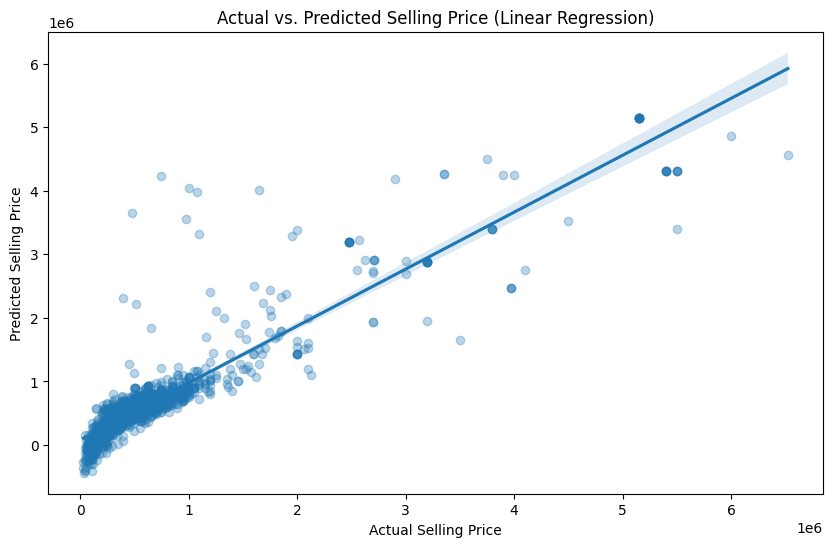

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5 # Root Mean Squared Error
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.3})
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs. Predicted Selling Price (Linear Regression)")
plt.show()

The model has been trained and evaluated. While a simple Linear Regression model provides a baseline, its performance (`R2` score) can likely be improved with more advanced models and hyperparameter tuning. For the purpose of building a Streamlit app to demonstrate car details and potential price predictions, this initial model will suffice. The next step is to prepare the Streamlit application.

## Building the Streamlit Application

To create the Streamlit application, we first need to save our trained model and the list of columns used for training (especially for one-hot encoded features). This ensures that the Streamlit app can load the model and process new input data consistently.

In [21]:
import joblib
import numpy as np
import pandas as pd
import re # Import re for regex functions

# Save the trained model
model_filename = 'linear_regression_model.joblib'
joblib.dump(model, model_filename)
print(f"Model saved as {model_filename}")

# Save the columns used for training (important for one-hot encoded features)
model_columns = X.columns.tolist()
columns_filename = 'model_columns.joblib'
joblib.dump(model_columns, columns_filename)
print(f"Model columns saved as {columns_filename}")

# --- Start of modifications for display_df ---

# Define functions for cleaning (copied from earlier cleaning step)
def extract_numeric(value):
    if isinstance(value, str):
        match = re.search(r'\d+\.?\d*', value)
        if match:
            return float(match.group(0))
    return value

def extract_torque(value):
    if isinstance(value, str):
        match_nm = re.search(r'(\d+\.?\d*)\s*Nm', value)
        if match_nm:
            return float(match_nm.group(1))
        match_kgm = re.search(r'(\d+\.?\d*)\s*kgm', value)
        if match_kgm:
            return float(match_kgm.group(1)) * 9.80665 # Convert kgm to Nm (approx)
        match_num = re.search(r'\d+\.?\d*', value)
        if match_num:
            return float(match_num.group(0))
    return value

# Reload original data to ensure we have the raw strings for display processing
original_df = pd.read_csv(data_filepath)

# Apply cleaning to the original_df columns that need it for display
# This ensures the numeric columns are actually numeric for st.metric
for col_name in ['mileage', 'engine', 'max_power', 'torque']:
    if col_name == 'torque':
        original_df[col_name] = original_df[col_name].apply(extract_torque)
    else:
        original_df[col_name] = original_df[col_name].apply(extract_numeric)

    original_df[col_name] = pd.to_numeric(original_df[col_name], errors='coerce')

    # Impute missing values with median for these numerical columns in original_df as well
    if original_df[col_name].isnull().any():
        median_val = original_df[col_name].median()
        original_df[col_name].fillna(median_val, inplace=True)

# Ensure 'seats' is also numeric and has no NaNs for display
original_df['seats'] = pd.to_numeric(original_df['seats'], errors='coerce')
if original_df['seats'].isnull().any():
    median_seats = original_df['seats'].median()
    original_df['seats'].fillna(median_seats, inplace=True)

# Now, create a display df that includes necessary info for the streamlit app with cleaned numerical columns
display_df = original_df[['name', 'year', 'selling_price', 'km_driven', 'fuel', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque', 'seats']].copy()
display_df.columns = ['Name', 'Year', 'Selling Price', 'Km Driven', 'Fuel', 'Transmission', 'Owner', 'Mileage', 'Engine (CC)', 'Max Power (bhp)', 'Torque', 'Seats']

display_df_filename = 'display_cars.joblib'
joblib.dump(display_df, display_df_filename)
print(f"Display DataFrame saved as {display_df_filename}")

Model saved as linear_regression_model.joblib
Model columns saved as model_columns.joblib
Display DataFrame saved as display_cars.joblib


/tmp/ipykernel_2848/2250288665.py:56: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  original_df[col_name].fillna(median_val, inplace=True)
/tmp/ipykernel_2848/2250288665.py:62: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

Now, let's create the Streamlit application script. This script will allow users to either select a car from the dataset to view its details or input custom features to get a price prediction. We will save this script as `app.py`.

In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# Load the trained model and columns
model = joblib.load('linear_regression_model.joblib')
model_columns = joblib.load('model_columns.joblib')

# Load the display DataFrame
display_df = joblib.load('display_cars.joblib')

# Explicitly ensure numeric types for display_df columns (robustness against potential joblib/caching issues)
display_df['Year'] = display_df['Year'].astype(int)
display_df['Selling Price'] = display_df['Selling Price'].astype(int)
display_df['Km Driven'] = display_df['Km Driven'].astype(int)
display_df['Mileage'] = display_df['Mileage'].astype(float)
display_df['Engine (CC)'] = display_df['Engine (CC)'].astype(int)
display_df['Max Power (bhp)'] = display_df['Max Power (bhp)'].astype(float)
display_df['Torque'] = display_df['Torque'].astype(float)
display_df['Seats'] = display_df['Seats'].astype(int)

st.set_page_config(layout="wide")
st.title('🚗 Car Price Predictor & Details App 📊')

# Sidebar for navigation or options
st.sidebar.header('⚙️ Options')
app_mode = st.sidebar.selectbox('Choose the app mode', ['Show Car Details', 'Predict Car Price'])

if app_mode == 'Show Car Details':
    st.header('🔍 Explore Car Details')

    # Dropdown to select a car
    selected_car_name = st.selectbox('Select a Car', display_df['Name'].unique())

    if selected_car_name:
        car_details = display_df[display_df['Name'] == selected_car_name].iloc[0]
        st.write('---')
        st.subheader(f'📝 Details for {selected_car_name}')

        # Display details in a structured way
        col1, col2, col3 = st.columns(3)
        with col1:
            st.metric(label="🗓️ Year", value=f"{car_details['Year']}")
            st.metric(label="⛽ Fuel Type", value=car_details['Fuel'])
            st.metric(label="👤 Owner Type", value=car_details['Owner'])
        with col2:
            st.metric(label="💰 Selling Price", value=f"₹ {car_details['Selling Price']:,}")
            st.metric(label="⚙️ Transmission", value=car_details['Transmission'])
            st.metric(label="エンジ Engine (CC)", value=f"{car_details['Engine (CC)']:,} CC")
        with col3:
            st.metric(label="🛣️ Km Driven", value=f"{car_details['Km Driven']:,} km")
            st.metric(label="📈 Mileage", value=f"{car_details['Mileage']:.2f} kmpl")
            st.metric(label="⚡ Max Power", value=f"{car_details['Max Power (bhp)']:.2f} bhp")
        st.metric(label="💪 Torque", value=f"{car_details['Torque']:.2f} Nm")
        st.metric(label="💺 Seats", value=f"{car_details['Seats']}")

elif app_mode == 'Predict Car Price':
    st.header('🔮 Predict Car Selling Price')

    st.write("Enter the details of the car to get a price prediction.")

    # Input fields for car features
    col1, col2, col3 = st.columns(3)
    with col1:
        year = st.slider('🗓️ Manufacturing Year', min_value=1980, max_value=2024, value=2015)
        km_driven = st.number_input('🛣️ Kilometers Driven', min_value=0, max_value=500000, value=50000)
        fuel_type = st.selectbox('⛽ Fuel Type', ['Diesel', 'Petrol', 'LPG', 'CNG'])
        seller_type = st.selectbox('👤 Seller Type', ['Individual', 'Dealer', 'Trustmark Dealer'])
    with col2:
        transmission_type = st.selectbox('⚙️ Transmission Type', ['Manual', 'Automatic'])
        owner_type = st.selectbox('🧑‍🤝‍ Owner Type', ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner'])
        mileage = st.number_input('📈 Mileage (kmpl)', min_value=0.0, max_value=50.0, value=18.0)
        engine = st.number_input('エンジ Engine (CC)', min_value=500, max_value=5000, value=1200)
    with col3:
        max_power = st.number_input('⚡ Max Power (bhp)', min_value=0.0, max_value=500.0, value=80.0)
        torque = st.number_input('💪 Torque (Nm)', min_value=0.0, max_value=1000.0, value=150.0)
        seats = st.slider('💺 Number of Seats', min_value=2, max_value=10, value=5)
        car_brand_options = sorted(list(set([x.split(' ')[0] for x in display_df['Name'].unique()]))) # Dynamically get brands
        brand = st.selectbox('📛 Car Brand', car_brand_options)

    # Create a DataFrame for prediction
    input_data = pd.DataFrame(np.zeros((1, len(model_columns))), columns=model_columns)

    # Fill in the values for the input data
    current_year = 2024
    input_data['km_driven'] = km_driven
    input_data['mileage'] = mileage
    input_data['engine'] = engine
    input_data['max_power'] = max_power
    input_data['torque'] = torque
    input_data['seats'] = seats
    input_data['car_age'] = current_year - year

    # Handle one-hot encoded categorical features
    if f'fuel_{fuel_type}' in input_data.columns: input_data[f'fuel_{fuel_type}'] = 1
    if f'seller_type_{seller_type}' in input_data.columns: input_data[f'seller_type_{seller_type}'] = 1
    if f'transmission_{transmission_type}' in input_data.columns: input_data[f'transmission_{transmission_type}'] = 1
    if f'owner_{owner_type}' in input_data.columns: input_data[f'owner_{owner_type}'] = 1
    if f'brand_{brand}' in input_data.columns: input_data[f'brand_{brand}'] = 1

    if st.button('💰 Predict Price'):
        prediction = model.predict(input_data)[0]
        st.success(f"Predicted Selling Price: ₹ {prediction:,.2f}")


Overwriting app.py


To run this Streamlit application in Google Colab, you need to follow these steps:

1.  **Install Streamlit:** If you haven't already, install Streamlit in your Colab environment by running: `!pip install streamlit`
2.  **Run the application:** Execute the following command in a new code cell:
    ```python
    !streamlit run app.py & npx localtunnel --port 8501
    ```

    After running this command, you will see a public URL (usually ending with `.loca.lt`). Click on this URL to open your Streamlit application in a new browser tab.

3.  **Stop the application:** To stop the Streamlit application and free up resources, click the square 'Stop' button next to the cell where you ran the `!streamlit run` command, or restart the Colab runtime.

This completes the analysis, model training, and Streamlit app creation as requested. You can now interact with the app to explore car details and get price predictions.

In [16]:
!pip install --ignore-installed blinker
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 2.8 MB/s eta 0:00:00
  Attempting uninstall: starlette
    Found existing installation: starlette 1.6.0
    Uninstalling starlette-1.6.0:
      Successfully uninstalled starlette-1.6.0


In [17]:
!pip install streamlit pyngrok

In [18]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [28]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [29]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &


2026-08-19 13:00:58.886 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.197.83.155:8501

  Stopping...
